# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

In [ ]:
%load_ext autoreload
%autoreload 2

In [21]:
# Клонируем свой форк репозитория с GitHub
!git clone https://github.com/QFXzZ/2025-Selyutin-TimeSeriesCourse.git

Cloning into '2025-Selyutin-TimeSeriesCourse'...
remote: Enumerating objects: 287, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 287 (delta 12), reused 3 (delta 3), pack-reused 234 (from 2)
Receiving objects: 100% (287/287), 242.13 MiB | 35.09 MiB/s, done.
Resolving deltas: 100% (27/27), done.
Updating files: 100% (198/198), done.


In [22]:
%cd 2025-Selyutin-TimeSeriesCourse/practice/"05 Snippets"

/content/2025-Selyutin-TimeSeriesCourse/practice/05 Snippets/2025-Selyutin-TimeSeriesCourse/practice/05 Snippets/2025-Selyutin-TimeSeriesCourse/practice/05 Snippets


In [23]:
!ls

'05 Snippets.ipynb'   datasets	 modules


Импорт библиотек и модулей

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from modules.snippets import *
from scipy import signal
from stumpy import snippets
import pandas as pd

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

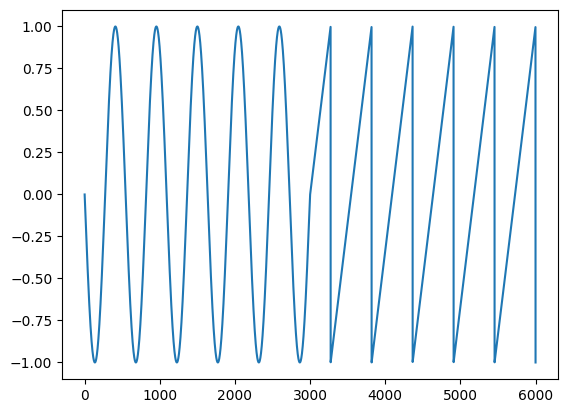

In [25]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [26]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


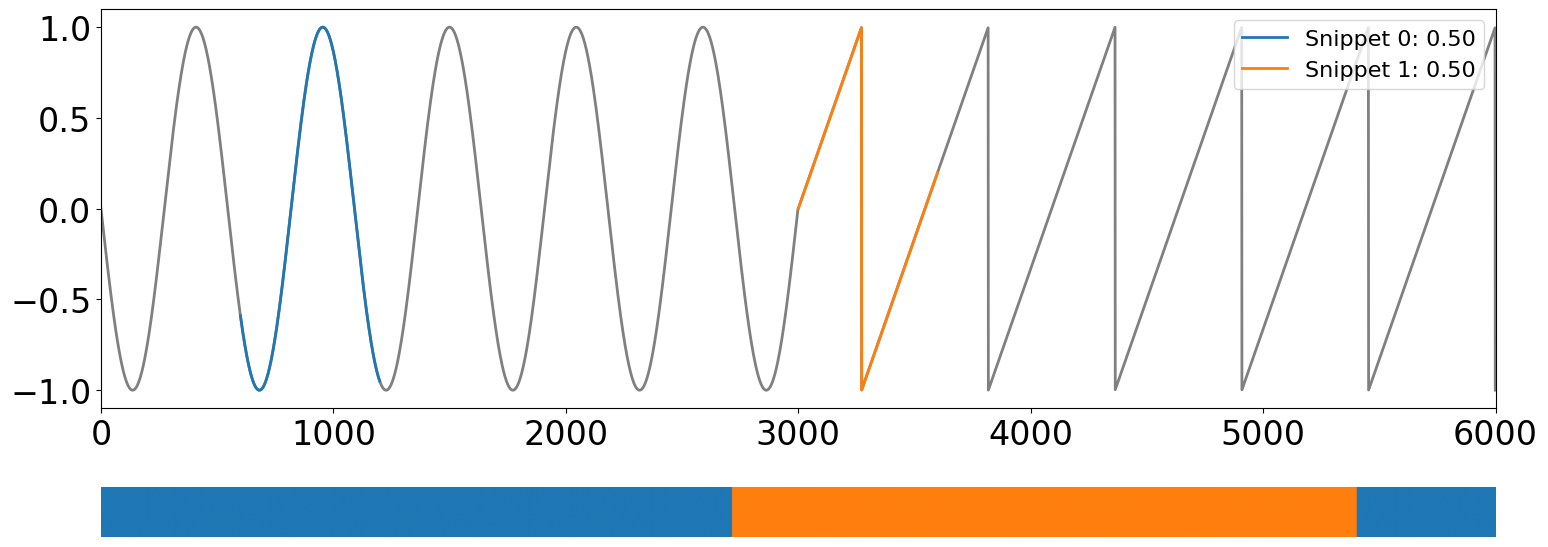

<Axes: >

In [27]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [28]:
# INSERT YOUR CODE
path = "./datasets/PAMAP/PAMAP.txt"

# Названия 54 столбцов полной спецификации PAMAP
cols = [
    "timestamp", "activityID", "heart_rate",

    # IMU hand (17 столбцов)
    "hand_temp",
    "hand_acc16_x", "hand_acc16_y", "hand_acc16_z",
    "hand_acc6_x", "hand_acc6_y", "hand_acc6_z",
    "hand_gyro_x", "hand_gyro_y", "hand_gyro_z",
    "hand_mag_x", "hand_mag_y", "hand_mag_z",
    "hand_orient1", "hand_orient2", "hand_orient3", "hand_orient4",

    # IMU chest (17 столбцов)
    "chest_temp",
    "chest_acc16_x", "chest_acc16_y", "chest_acc16_z",
    "chest_acc6_x", "chest_acc6_y", "chest_acc6_z",
    "chest_gyro_x", "chest_gyro_y", "chest_gyro_z",
    "chest_mag_x", "chest_mag_y", "chest_mag_z",
    "chest_orient1", "chest_orient2", "chest_orient3", "chest_orient4",

    # IMU ankle (17 столбцов)
    "ankle_temp",
    "ankle_acc16_x", "ankle_acc16_y", "ankle_acc16_z",
    "ankle_acc6_x", "ankle_acc6_y", "ankle_acc6_z",
    "ankle_gyro_x", "ankle_gyro_y", "ankle_gyro_z",
    "ankle_mag_x", "ankle_mag_y", "ankle_mag_z",
    "ankle_orient1", "ankle_orient2", "ankle_orient3", "ankle_orient4",
]

In [29]:
df = pd.read_csv(path, sep=r"\s+", header=None, names=cols, na_values=["NaN"])

print("Загружен")

Загружен


Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

In [ ]:
# INSERT YOUR CODE

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [ ]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

In [ ]:
# INSERT YOUR CODE

Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [ ]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Сравните полученные разметки многомерного и одномерного рядов.

## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [ ]:
# INSERT YOUR CODE

Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

In [ ]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Какое значение $k$ является наилучшим для используемого временного ряда?